# Augmentation


*  Slight rotation
*  elastic distortion
*  thickness variation


### Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import matplotlib.gridspec as gridspec
import warnings; warnings.filterwarnings('ignore')
import os
import cv2
import hashlib
import random
from collections import Counter
from google.colab import drive
np.random.seed(42)

### Load Data

In [3]:
drive.mount('/drive')
CSV_PATH = "/drive/MyDrive/ML/A_Z Handwritten Data.csv"

# Confirm full file
size_mb = os.path.getsize(CSV_PATH) / 1e6
print(f"File size: {size_mb:.1f} MB")

Mounted at /drive
File size: 698.9 MB


In [4]:
SAVE_DIR = "/drive/MyDrive/ML/processed_data/"
os.makedirs(SAVE_DIR, exist_ok=True)

In [6]:
data = np.load(SAVE_DIR + "az_dataset_full.npz")
images = data["images"]
labels = data["labels"]

In [7]:
data = np.load(SAVE_DIR + "az_dataset_splits.npz")

X_train = data["X_train"]
X_val   = data["X_val"]
X_test  = data["X_test"]
y_train = data["y_train"]
y_val   = data["y_val"]
y_test  = data["y_test"]

### Duplicate Handling

In [8]:
#Duplicate check
print("Checking for duplicate images\n")
# Flatten each image to a 1D vector for hashing
X_flat = images.reshape(len(images), -1)
# Hash every image row
hashes = [hash(row.tobytes()) for row in X_flat]
total        = len(hashes)
unique_count = len(set(hashes))
duplicates   = total - unique_count
print(f"Total images     : {total:,}")
print(f"Unique images    : {unique_count:,}")
print(f"Duplicate images : {duplicates:,}")
if duplicates == 0:
    print("\nNo duplicates found — every image is unique.")
else:
    print(f"\n{duplicates:,} duplicates detected!")

Checking for duplicate images

Total images     : 372,451
Unique images    : 201,096
Duplicate images : 171,355

171,355 duplicates detected!


In [9]:
#Remove duplicates
def hash_image(img):
    return hashlib.md5(img.tobytes()).hexdigest()
seen = set()
unique_indices = []
for i, img in enumerate(images):
    h = hash_image(img)
    if h not in seen:
        seen.add(h)
        unique_indices.append(i)

images_clean = images[unique_indices]
labels_clean = labels[unique_indices]
print("Before:", len(images))
print("After :", len(images_clean))

Before: 372451
After : 201096


### Imbalance Handling

In [10]:
# ---------- 1. Set deterministic seeds ----------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

#augmentation helpers
def augment_image(img):
    """Accepts any shape: (H,W), (H,W,C). Returns same shape."""
    ops = np.random.choice([
        'rotate', 'shift', 'zoom',
        'brightness', 'elastic'
    ], size=np.random.randint(2, 5), replace=False)

    for op in ops:
        if op == 'rotate':
            angle = np.random.uniform(-15, 15)
            h, w  = img.shape[:2]
            M     = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
            img   = cv2.warpAffine(img, M, (w, h),
                                   borderMode=cv2.BORDER_REFLECT_101)

        elif op == 'shift':
            h, w = img.shape[:2]
            tx   = np.random.uniform(-0.1, 0.1) * w
            ty   = np.random.uniform(-0.1, 0.1) * h
            M    = np.float32([[1, 0, tx], [0, 1, ty]])
            img  = cv2.warpAffine(img, M, (w, h),
                                  borderMode=cv2.BORDER_REFLECT_101)

        elif op == 'zoom':
            scale = np.random.uniform(0.85, 1.15)
            h, w  = img.shape[:2]
            M     = cv2.getRotationMatrix2D((w/2, h/2), 0, scale)
            img   = cv2.warpAffine(img, M, (w, h),
                                   borderMode=cv2.BORDER_REFLECT_101)

        elif op == 'brightness':
            delta = np.random.uniform(-30, 30)
            img   = np.clip(img.astype(np.float32) + delta, 0, 255).astype(np.uint8)

        # elif op == 'noise':
        #     noise = np.random.normal(0, 8, img.shape).astype(np.float32)
        #     img   = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

        elif op == 'elastic':
            h, w  = img.shape[:2]
            dx    = cv2.GaussianBlur(
                        (np.random.rand(h, w) * 2 - 1).astype(np.float32),
                        (15, 15), 5) * 8
            dy    = cv2.GaussianBlur(
                        (np.random.rand(h, w) * 2 - 1).astype(np.float32),
                        (15, 15), 5) * 8
            x, y  = np.meshgrid(np.arange(w), np.arange(h))
            map_x = np.clip(x + dx, 0, w - 1).astype(np.float32)
            map_y = np.clip(y + dy, 0, h - 1).astype(np.float32)
            img   = cv2.remap(img, map_x, map_y, cv2.INTER_LINEAR,
                              borderMode=cv2.BORDER_REFLECT_101)
    return img

sample     = X_train[0]
orig_shape = sample.shape

def to_hwc(img):
    if img.ndim == 1:
        side = int(np.sqrt(img.shape[0]))
        return img.reshape(side, side)
    return img

def restore_shape(img, shape):
    return img.reshape(shape)

# ---------- 3. Hash function for exact duplicate detection ----------
def hash_image(img):
    return hashlib.md5(img.tobytes()).hexdigest()

# ---------- 4. Balancing with post‑dedup and re‑balancing ----------
TARGET = 2000
X_bal_list, y_bal_list = [], []

for cls in range(26):
    cls_idx = np.where(y_train == cls)[0]
    X_cls = X_train[cls_idx]
    n = len(cls_idx)

    if n >= TARGET:
        chosen = np.random.choice(n, size=TARGET, replace=False)
        X_bal_list.append(X_cls[chosen])
        y_bal_list.append(np.full(TARGET, cls))
    else:
        needed = TARGET - n
        # Generate augmented images (allow duplicates for now; will clean later)
        aug_idx = np.random.choice(n, size=needed, replace=True)
        X_aug = []
        for i in aug_idx:
            img = X_cls[i].copy()
            img = to_hwc(img)
            img = augment_image(img)
            img = restore_shape(img, orig_shape)
            X_aug.append(img)
        X_aug_arr = np.array(X_aug)
        X_bal_list.append(np.concatenate([X_cls, X_aug_arr], axis=0))
        y_bal_list.append(np.full(TARGET, cls))

X_train_bal = np.concatenate(X_bal_list, axis=0)
y_train_bal = np.concatenate(y_bal_list, axis=0)

# ---------- 5. Remove exact duplicates globally ----------
unique_indices = []
seen_hashes = set()
for i, img in enumerate(X_train_bal):
    h = hash_image(img)
    if h not in seen_hashes:
        seen_hashes.add(h)
        unique_indices.append(i)

X_unique = X_train_bal[unique_indices]
y_unique = y_train_bal[unique_indices]

print(f"After duplicate removal: {X_unique.shape[0]} images (was {X_train_bal.shape[0]})")

# ---------- 6. Check per‑class counts after dedup ----------
unique_counts = Counter(y_unique)
under_target = [cls for cls in range(26) if unique_counts.get(cls, 0) < TARGET]

if under_target:
    print(f"Classes below {TARGET} after dedup: {under_target}")
    # For each deficient class, generate additional UNIQUE augmentations
    final_X = []
    final_y = []
    for cls in range(26):
        cls_mask = (y_unique == cls)
        X_cls_unique = X_unique[cls_mask]
        current_cnt = len(X_cls_unique)
        if current_cnt >= TARGET:
            # Keep only TARGET (already satisfied after dedup)
            final_X.append(X_cls_unique[:TARGET])
            final_y.append(np.full(TARGET, cls))
        else:
            needed = TARGET - current_cnt
            # Get original images for this class (pre‑augmentation)
            orig_mask = (y_train == cls)
            X_orig_cls = X_train[orig_mask]
            # Build a set of hashes already present in the unique set for this class
            existing_hashes = {hash_image(img) for img in X_cls_unique}
            new_aug_images = []
            # Keep trying augmentations until we have enough unique ones
            while len(new_aug_images) < needed:
                # Sample an original image (with replacement, but we will hash-check)
                idx = np.random.choice(len(X_orig_cls))
                img = X_orig_cls[idx].copy()
                img = to_hwc(img)
                img = augment_image(img)
                img = restore_shape(img, orig_shape)
                h = hash_image(img)
                if h not in existing_hashes:
                    existing_hashes.add(h)
                    new_aug_images.append(img)
            new_aug_arr = np.array(new_aug_images)
            final_X.append(np.concatenate([X_cls_unique, new_aug_arr], axis=0))
            final_y.append(np.full(TARGET, cls))
    X_train_bal = np.concatenate(final_X, axis=0)
    y_train_bal = np.concatenate(final_y, axis=0)
else:
    # No classes under target; just trim each class to exactly TARGET
    final_X = []
    final_y = []
    for cls in range(26):
        cls_mask = (y_unique == cls)
        X_cls = X_unique[cls_mask]
        if len(X_cls) > TARGET:
            # Randomly sample down
            idx = np.random.choice(len(X_cls), size=TARGET, replace=False)
            X_cls = X_cls[idx]
        final_X.append(X_cls)
        final_y.append(np.full(len(X_cls), cls))
    X_train_bal = np.concatenate(final_X, axis=0)
    y_train_bal = np.concatenate(final_y, axis=0)

perm = np.random.permutation(len(y_train_bal))
X_train_bal = X_train_bal[perm]
y_train_bal = y_train_bal[perm]

print(f"\nFinal balanced shape : {X_train_bal.shape}")
print(f"Per‑class counts     : {dict(sorted(Counter(y_train_bal).items()))}")

hashes_final = [hash_image(img) for img in X_train_bal]
print(f"Duplicates after fix : {len(hashes_final) - len(set(hashes_final))}")

After duplicate removal: 47087 images (was 52000)
Classes below 2000 after dedup: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]

Final balanced shape : (52000, 28, 28, 1)
Per‑class counts     : {np.int64(0): 2000, np.int64(1): 2000, np.int64(2): 2000, np.int64(3): 2000, np.int64(4): 2000, np.int64(5): 2000, np.int64(6): 2000, np.int64(7): 2000, np.int64(8): 2000, np.int64(9): 2000, np.int64(10): 2000, np.int64(11): 2000, np.int64(12): 2000, np.int64(13): 2000, np.int64(14): 2000, np.int64(15): 2000, np.int64(16): 2000, np.int64(17): 2000, np.int64(18): 2000, np.int64(19): 2000, np.int64(20): 2000, np.int64(21): 2000, np.int64(22): 2000, np.int64(23): 2000, np.int64(24): 2000, np.int64(25): 2000}
Duplicates after fix : 36


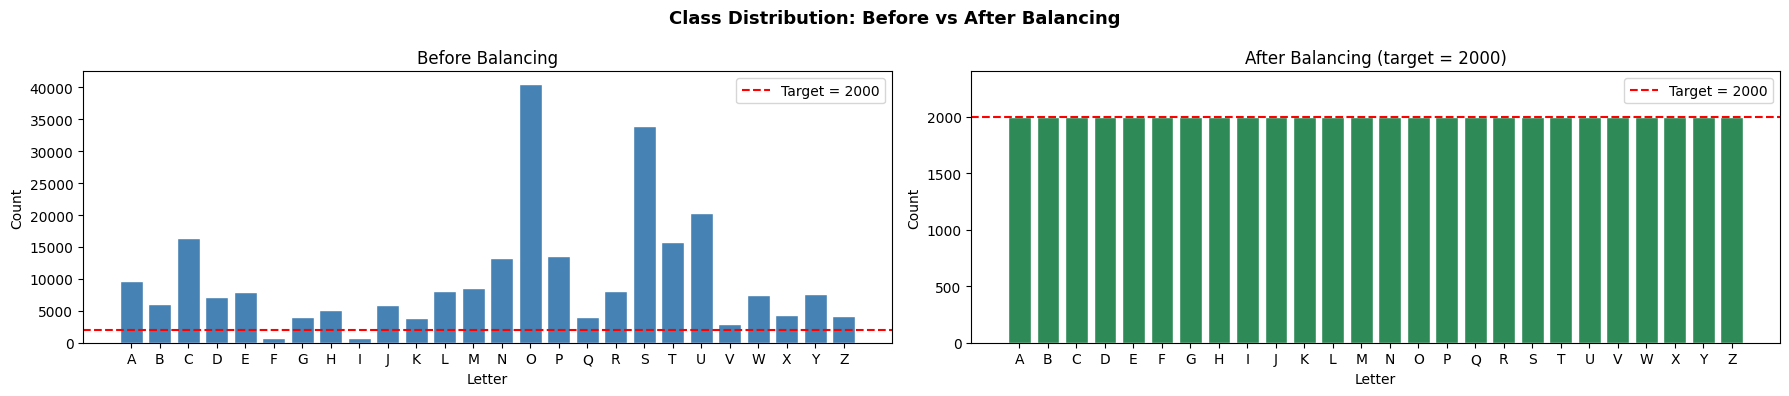


Total samples  — Before: 260,715  |  After: 52,000
Unique classes — Before: 26  |  After: 26


In [11]:
LETTER_MAP = {i: chr(65 + i) for i in range(26)}
unique, counts = np.unique(y_train_bal, return_counts=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 4))

# ── Before ────────────────────────────────────────────────────────────────────
unique_orig, counts_orig = np.unique(y_train, return_counts=True)
axes[0].bar([LETTER_MAP[i] for i in unique_orig], counts_orig,
            color="steelblue", edgecolor="white")
axes[0].axhline(TARGET, color="red", linestyle="--", linewidth=1.5, label=f"Target = {TARGET}")
axes[0].set_title("Before Balancing")
axes[0].set_xlabel("Letter")
axes[0].set_ylabel("Count")
axes[0].legend()

# ── After ─────────────────────────────────────────────────────────────────────
axes[1].bar([LETTER_MAP[i] for i in unique], counts,
            color="seagreen", edgecolor="white")
axes[1].axhline(TARGET, color="red", linestyle="--", linewidth=1.5, label=f"Target = {TARGET}")
axes[1].set_ylim(0, TARGET * 1.2)
axes[1].set_title(f"After Balancing (target = {TARGET})")
axes[1].set_xlabel("Letter")
axes[1].set_ylabel("Count")
axes[1].legend()
plt.suptitle("Class Distribution: Before vs After Balancing", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nTotal samples  — Before: {len(y_train):,}  |  After: {len(y_train_bal):,}")
print(f"Unique classes — Before: {len(unique_orig)}  |  After: {len(unique)}")

## Agumantation

### 1. Shear Function

In [12]:
def apply_shear(img):
    """Horizontal shear — tilts strokes diagonally, simulates slanted writing."""
    h, w  = img.shape[:2]
    shear = np.random.uniform(-0.25, 0.25)
    M     = np.float32([[1, shear, 0], [0, 1, 0]])
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT_101)

### 2. perspective Function

In [13]:
def apply_perspective(img):
    """4-corner warp — simulates camera angle or paper tilt."""
    h, w   = img.shape[:2]
    margin = max(1, int(min(h, w) * 0.10))
    src    = np.float32([[0,0],[w,0],[0,h],[w,h]])
    dst    = np.float32([
        [np.random.randint(0, margin),     np.random.randint(0, margin)],
        [w - np.random.randint(0, margin), np.random.randint(0, margin)],
        [np.random.randint(0, margin),     h - np.random.randint(0, margin)],
        [w - np.random.randint(0, margin), h - np.random.randint(0, margin)],
    ])
    M = cv2.getPerspectiveTransform(src, dst)
    return cv2.warpPerspective(img, M, (w, h), borderMode=cv2.BORDER_REFLECT_101)

### 3. Sharpen Functions

In [14]:
def apply_sharpen(img):
    """Unsharp-mask sharpening — emphasises stroke edges."""
    kernel = np.array([[ 0, -1,  0],
                       [-1,  5, -1],
                       [ 0, -1,  0]], dtype=np.float32)
    return np.clip(cv2.filter2D(img, -1, kernel), 0, 255).astype(np.uint8)

### Combined Augmentation Function

Even though EMNIST-Balanced has equal class sizes, augmentation still helps the model
**generalise** to unseen handwriting styles by randomly varying the training images at
each epoch.  We use only *mild* transforms — aggressive distortions on 28 × 28 images
can destroy the character's shape.

applied **only during training**

In [15]:
if X_train_bal.ndim == 4 and X_train_bal.shape[-1] == 1:
    X_train_bal_3d = X_train_bal.squeeze(-1)   # (N, H, W)
else:
    X_train_bal_3d = X_train_bal
augmentation_list = [
    (apply_shear, 'Shear'),
    (apply_perspective, 'Perspective'),
    (apply_sharpen, 'Sharpen')
]

X_aug = []
y_aug = []
aug_methods = []

for i in range(len(X_train_bal_3d)):
    img = X_train_bal_3d[i].copy()
    # Pick random index
    idx = np.random.randint(len(augmentation_list))
    aug_func, method_name = augmentation_list[idx]
    img_aug = aug_func(img)
    X_aug.append(img_aug)
    y_aug.append(y_train_bal[i])
    aug_methods.append(method_name)

X_aug = np.array(X_aug)    # shape (N, H, W)
y_aug = np.array(y_aug)
print("Augmentation methods distribution:")
from collections import Counter
print(Counter(aug_methods))

Augmentation methods distribution:
Counter({'Perspective': 17473, 'Shear': 17353, 'Sharpen': 17174})


In [16]:
#Concatenate original + augmented
# Ensure X_aug has exactly the same ndim and channel convention as X_train_bal
def normalize_to_4d(arr, target_shape):
    """Convert arr to 4D (N, H, W, C) with C=1 if target has channel 1."""
    if arr.ndim == 3:          # (N, H, W) → add channel dim
        arr = np.expand_dims(arr, axis=-1)
    elif arr.ndim == 4:
        # Already 4D; ensure channel dimension matches target's last dim (1)
        if arr.shape[-1] != target_shape[-1]:
            # If channel dim is at axis=1? Unlikely. But we can squeeze/expand.
            if arr.shape[-1] == 1 and target_shape[-1] == 1:
                pass  # OK
            elif arr.shape[-1] != 1 and target_shape[-1] == 1:
                # Take mean or just keep first channel – but we assume grayscale
                arr = arr[..., 0:1]  # if multiple channels, take one
    elif arr.ndim == 5:
        # Remove extra singleton dims: e.g., (N, H, W, 1, 1) → (N, H, W, 1)
        arr = arr.reshape(arr.shape[0], *arr.shape[1:3], -1)
        if arr.ndim == 5:
            arr = arr.squeeze()  # last resort
    return arr

X_aug = normalize_to_4d(X_aug, X_train_bal.shape)
X_final = np.concatenate([X_train_bal, X_aug], axis=0)
y_final = np.concatenate([y_train_bal, y_aug], axis=0)

# Shuffle
perm = np.random.permutation(len(y_final))
X_final = X_final[perm]
y_final = y_final[perm]

print(f"Final training set shape: {X_final.shape}")

Final training set shape: (104000, 28, 28, 1)


In [17]:
def hash_image(img):
    return hashlib.md5(img.tobytes()).hexdigest()

hashes = [hash_image(img) for img in X_final]
unique_count = len(set(hashes))
print(f"Total images: {len(hashes)}, Unique: {unique_count}, Duplicates: {len(hashes)-unique_count}")

Total images: 104000, Unique: 103785, Duplicates: 215


In [18]:
#Shuffle final dataset (preserve pairing)
perm = np.random.permutation(len(y_final))
X_final = X_final[perm]
y_final = y_final[perm]

In [19]:
print(f"Final training set shape: {X_final.shape}")

Final training set shape: (104000, 28, 28, 1)


### Visualize the Augmentations

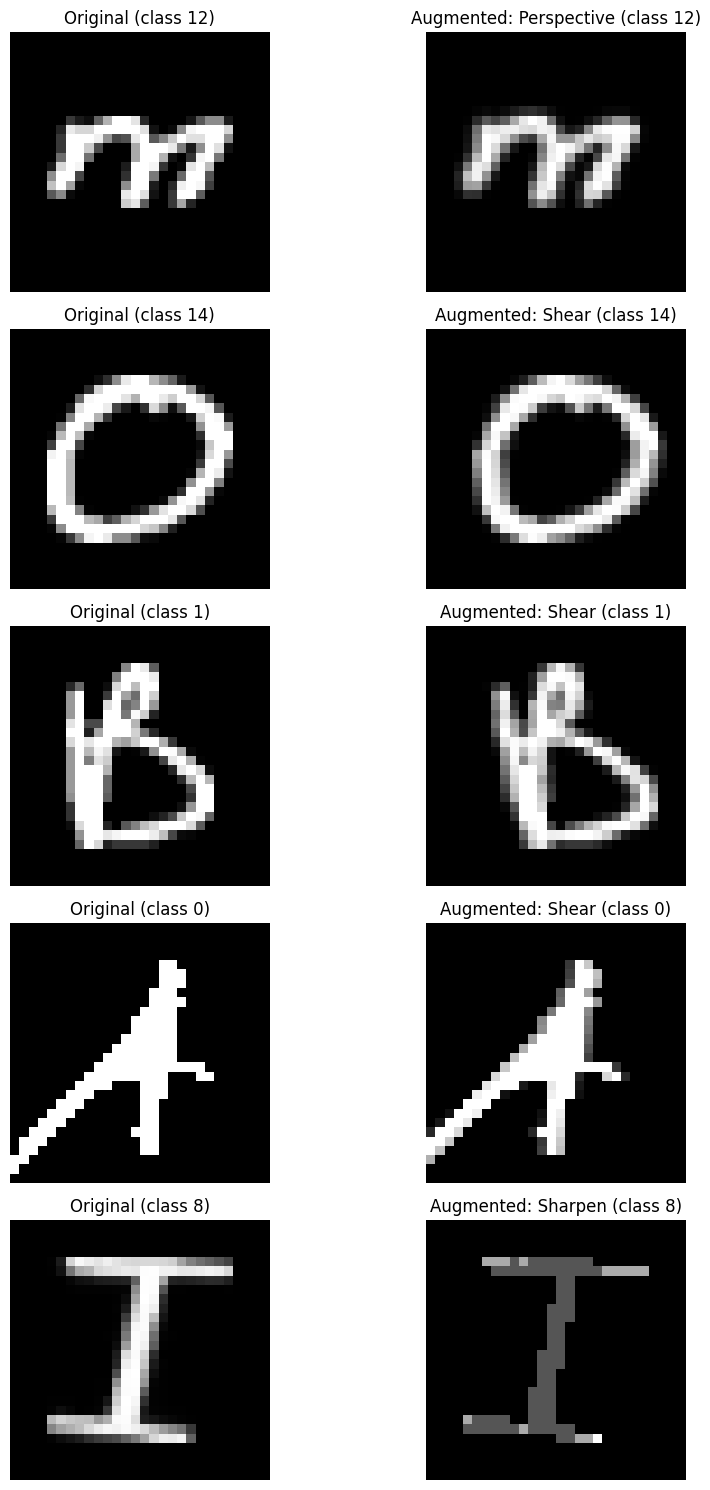

In [20]:
n_samples = 5
fig, axes = plt.subplots(n_samples, 2, figsize=(10, 3*n_samples))

for i in range(n_samples):
    idx = np.random.randint(0, len(X_train_bal))
    orig = X_train_bal[idx]
    aug  = X_aug[idx]
    method = aug_methods[idx]          # get the stored method name

    # Squeeze channel for display
    if orig.ndim == 3 and orig.shape[-1] == 1:
        orig = orig.squeeze(-1)
        aug  = aug.squeeze(-1)

    # Original image
    axes[i, 0].imshow(orig, cmap='gray')
    axes[i, 0].set_title(f"Original (class {y_train_bal[idx]})")
    axes[i, 0].axis('off')

    # Augmented image with method label
    axes[i, 1].imshow(aug, cmap='gray')
    axes[i, 1].set_title(f"Augmented: {method} (class {y_aug[idx]})")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

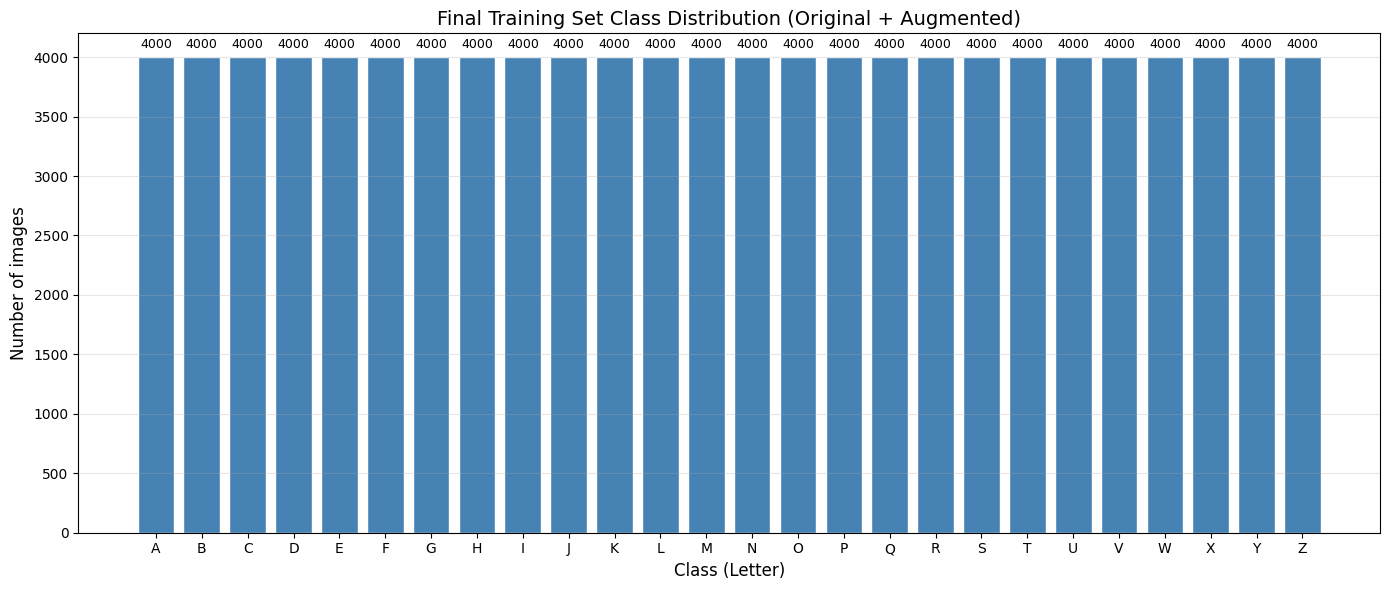

Total images in final training set: 104,000
  Class  1 (B): 4000
  Class  5 (F): 4000
  Class 11 (L): 4000
  Class 22 (W): 4000
  Class 20 (U): 4000
  Class 16 (Q): 4000
  Class 23 (X): 4000
  Class  0 (A): 4000
  Class 13 (N): 4000
  Class  6 (G): 4000
  Class  4 (E): 4000
  Class 24 (Y): 4000
  Class 10 (K): 4000
  Class 17 (R): 4000
  Class 21 (V): 4000
  Class  7 (H): 4000
  Class 15 (P): 4000
  Class 12 (M): 4000
  Class 25 (Z): 4000
  Class  3 (D): 4000
  Class 14 (O): 4000
  Class 18 (S): 4000
  Class  9 (J): 4000
  Class  8 (I): 4000
  Class  2 (C): 4000
  Class 19 (T): 4000


In [21]:
# Get class counts from final labels
class_counts = Counter(y_final)

# Sort by class index (0 to 25)
classes = sorted(class_counts.keys())
counts = [class_counts[c] for c in classes]

# Map class numbers to letters (correct way)
LETTER_MAP = {i: chr(65+i) for i in range(26)}   # 0:'A', 1:'B', ..., 25:'Z'
class_labels = [LETTER_MAP[c] for c in classes]

# Plot
plt.figure(figsize=(14, 6))
plt.bar(classes, counts, color='steelblue', edgecolor='white')
plt.xlabel("Class (Letter)", fontsize=12)
plt.ylabel("Number of images", fontsize=12)
plt.title("Final Training Set Class Distribution (Original + Augmented)", fontsize=14)
plt.xticks(classes, class_labels, rotation=0)
plt.grid(axis='y', alpha=0.3)

# Add value labels on top of each bar
for i, (cls, cnt) in enumerate(zip(classes, counts)):
    plt.text(cls, cnt + 50, str(cnt), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Summary statistics
print(f"Total images in final training set: {len(y_final):,}")
for cls, cnt in class_counts.items():
    print(f"  Class {cls:2d} ({chr(65+cls)}): {cnt:4d}")

### Save Data

In [22]:
# np.savez_compressed(
#     SAVE_DIR + "az_dataset_splits.npz",
#     X_train=X_final,
#     y_train=y_final
# )